In [1]:
print("Project Started Successfully")


Project Started Successfully


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
df = pd.read_excel("../Data/Processed_Flipdata.xlsx")

Data Exploration

Purpose: Why are we doing this?

Understand dataset size.
Identify numerical and categorical columns.
Detect missing values.
Detect duplicate records.
Understand distributions before cleaning.

In [7]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [8]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    str    
 7   Front Camera   541 non-null    str    
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 50.8 KB


np.int64(0)



Data cleaning

Check Missing Values

In [12]:
df.isnull().sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

Check Duplicate Values

In [13]:
df.duplicated().sum()

np.int64(10)

In [15]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(531, 11)

In [17]:
df.isnull().sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [18]:
df['Rear Camera'].unique()[:10]

<StringArray>
['13MP', '50MP', '8MP', '40MP', '32MP', '48MP', '64MP', '108MP', '0MP', '2MP']
Length: 10, dtype: str

In [19]:
df['Front Camera'].unique()[:10]

<StringArray>
['5MP', '16MP', '8MP', '13MP', '0MP', '32MP', '10MP', '50MP', '60MP', '20MP']
Length: 10, dtype: str

This tells us the camera columns are actually numeric values stored as text.
We need to convert them into numbers.

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 531 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          531 non-null    str    
 1   Colour         531 non-null    str    
 2   Memory         531 non-null    int64  
 3   RAM            531 non-null    int64  
 4   Battery_       531 non-null    int64  
 5   Rear Camera    531 non-null    int64  
 6   Front Camera   531 non-null    int64  
 7   AI Lens        531 non-null    int64  
 8   Mobile Height  531 non-null    float64
 9   Processor_     531 non-null    str    
 10  Prize          531 non-null    int64  
dtypes: float64(1), int64(7), str(3)
memory usage: 49.8 KB


# Univariate Analysis
Purpose: To study the distribution of individual variables.


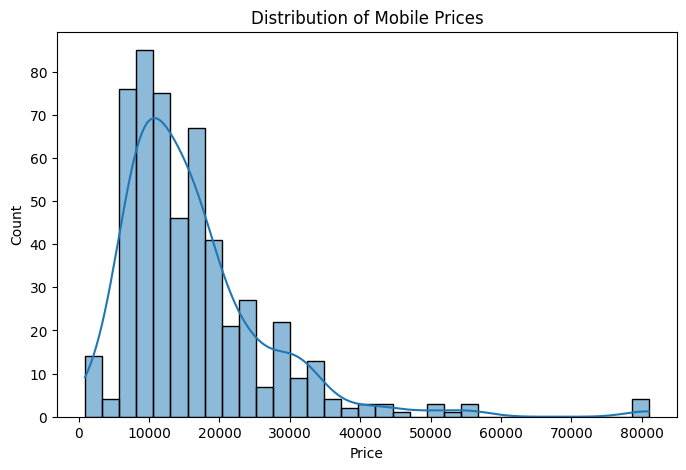

In [25]:
#Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Prize'], kde=True)
plt.title('Distribution of Mobile Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

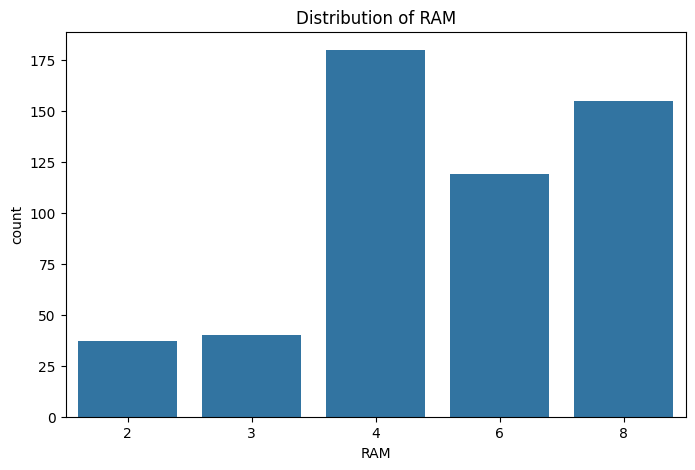

In [26]:
#RAM Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='RAM', data=df)
plt.title('Distribution of RAM')
plt.show()

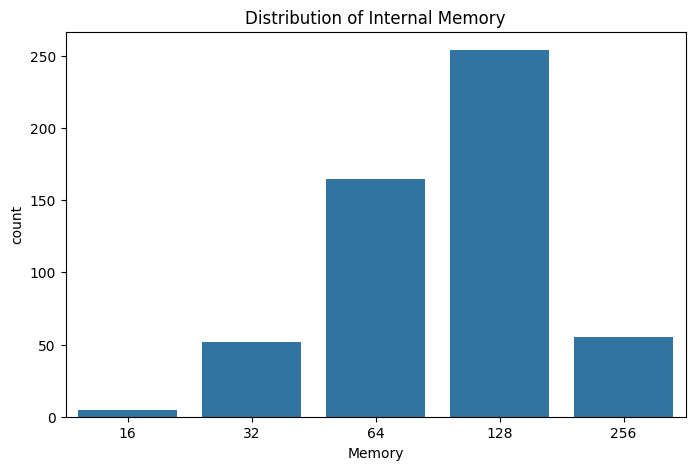

In [27]:
#Memory Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='Memory', data=df)
plt.title('Distribution of Internal Memory')
plt.show()

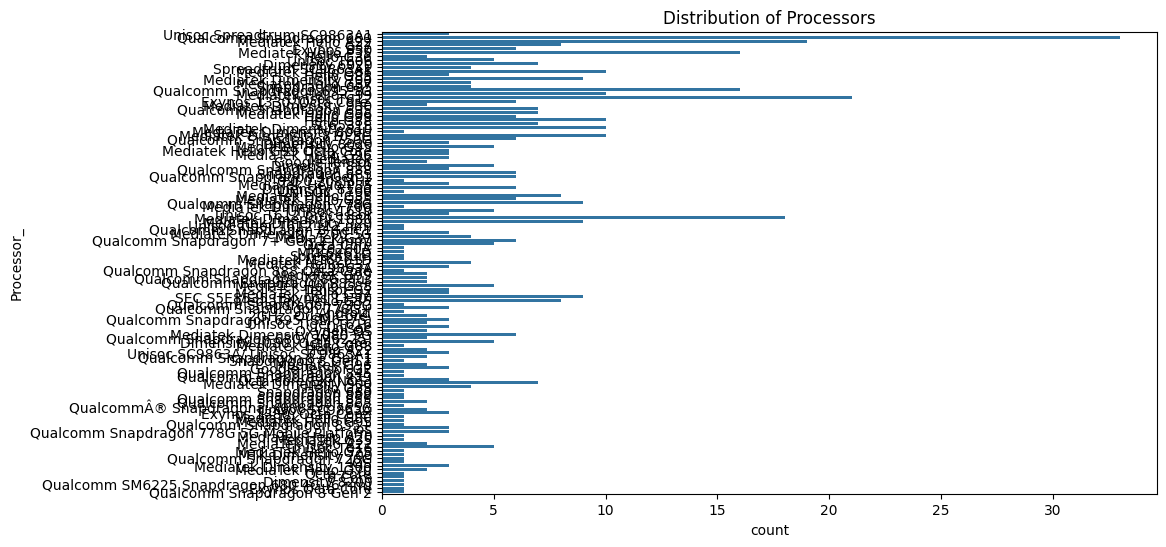

In [28]:
#Processor Distribution.

plt.figure(figsize=(10,6))
sns.countplot(y='Processor_', data=df)
plt.title('Distribution of Processors')
plt.show()

 Outlier Detection

In [29]:
df.describe()

,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Prize
count,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000
mean,110.915254,5.401130,4873.877589,46.227872,12.045198,0.064030,16.450019,16305.775895
std,60.872883,1.991283,765.883129,31.392146,9.105142,0.245037,2.494246,10847.038354
min,16.000000,2.000000,800.000000,0.000000,0.000000,0.000000,4.500000,920.000000
25%,64.000000,4.000000,5000.000000,13.000000,5.000000,0.000000,16.510000,9368.000000
50%,128.000000,6.000000,5000.000000,50.000000,8.000000,0.000000,16.710000,13999.000000
75%,128.000000,8.000000,5000.000000,50.000000,16.000000,0.000000,16.940000,19338.500000
max,256.000000,8.000000,7000.000000,200.000000,60.000000,1.000000,41.940000,80999.000000


Box plots : Boxplots were used to identify extreme values and potential outliers in the numerical variables.

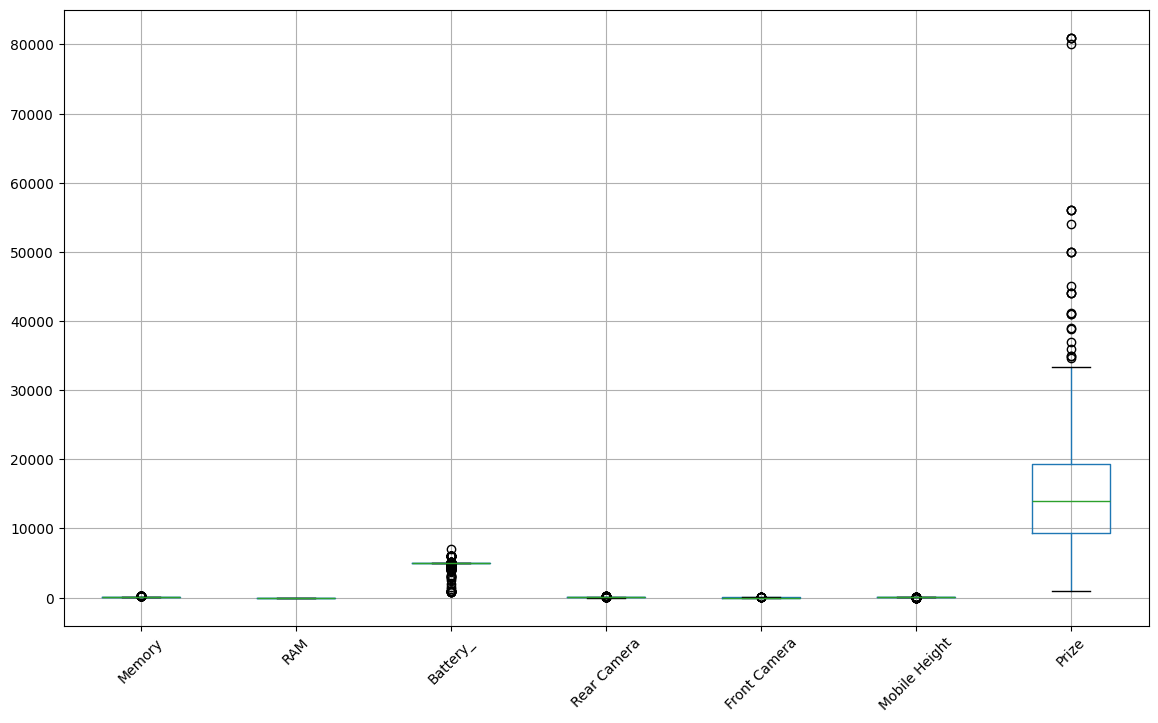

In [30]:
numeric_cols = ['Memory',
                'RAM',
                'Battery_',
                'Rear Camera',
                'Front Camera',
                'Mobile Height',
                'Prize']

plt.figure(figsize=(14,8))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.show()

Outlier Detection

Boxplots and IQR methods were used to identify extreme values in numerical variables.

Although outliers were detected in the Price, Battery, and Camera features, they were retained because they represent genuine premium mobile phones rather than erroneous observations.



In [31]:
#Calculate outliers

Q1 = df[['Memory','RAM','Battery_',
         'Rear Camera','Front Camera',
         'Mobile Height','Prize']].quantile(0.25)

Q3 = df[['Memory','RAM','Battery_',
         'Rear Camera','Front Camera',
         'Mobile Height','Prize']].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [32]:
outliers = ((df[['Memory','RAM','Battery_',
                 'Rear Camera','Front Camera',
                 'Mobile Height','Prize']] < lower) |
            (df[['Memory','RAM','Battery_',
                 'Rear Camera','Front Camera',
                 'Mobile Height','Prize']] > upper))

outliers.sum()

Memory            55
RAM                0
Battery_         148
Rear Camera       39
Front Camera      13
Mobile Height     32
Prize             25
dtype: int64

Bivariate Analysis : Observations 

RAM vs Price → Strong upward trend. More RAM (6 GB, 8 GB) consistently links to higher prices.

Memory vs Price → Moderate positive relationship. Higher memory (128 GB, 256 GB) tends to increase price, but variation exists.

Rear Camera vs Price → Weak to moderate. Some clustering at 50 MP, 108 MP, 200 MP, but scatter shows inconsistency.

Front Camera vs Price → Weak. Devices with similar front cameras (8 MP, 16 MP) vary widely in price.

Processor vs Price (box plot) → Very strong. Premium processors (Snapdragon 8 Gen 1, Dimensity 8100, Snapdragon 778G) clearly drive higher prices.

Battery vs Price → Weak to moderate. Most phones cluster around 5000–6000 mAh, but prices vary widely. Battery capacity alone doesn’t strongly determine price.

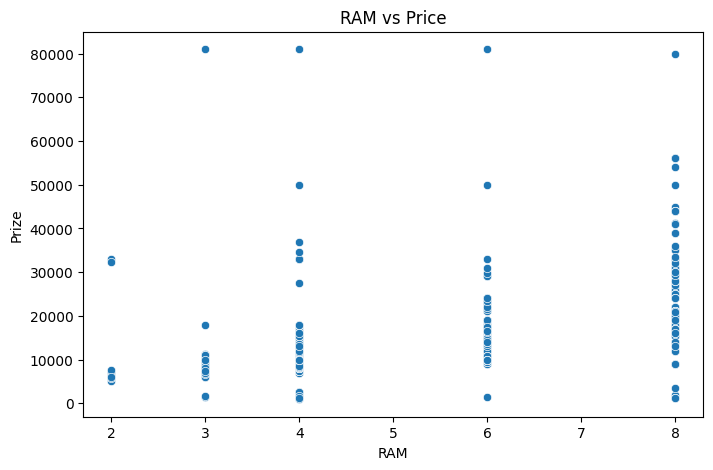

In [33]:
# RAM vs Price

plt.figure(figsize=(8,5))
sns.scatterplot(x='RAM', y='Prize', data=df)
plt.title('RAM vs Price')
plt.show()

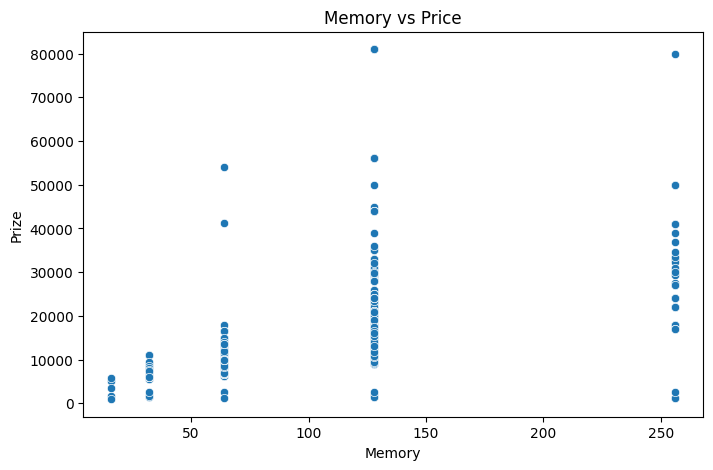

In [34]:
#Memory Vs Price

plt.figure(figsize=(8,5))
sns.scatterplot(x='Memory', y='Prize', data=df)
plt.title('Memory vs Price')
plt.show()

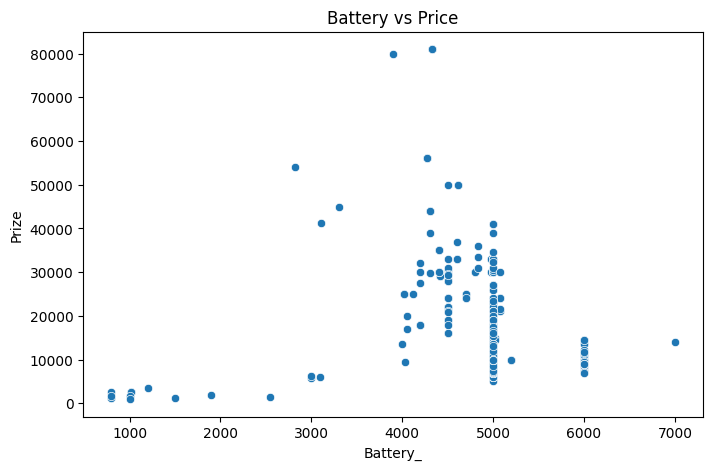

In [35]:
#Battery VS Price

plt.figure(figsize=(8,5))
sns.scatterplot(x='Battery_', y='Prize', data=df)
plt.title('Battery vs Price')
plt.show()

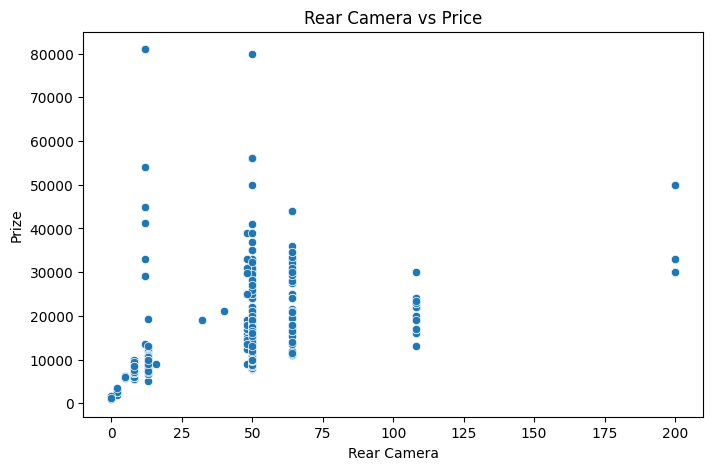

In [36]:
# Rear camera Vs Price

plt.figure(figsize=(8,5))
sns.scatterplot(x='Rear Camera', y='Prize', data=df)
plt.title('Rear Camera vs Price')
plt.show()

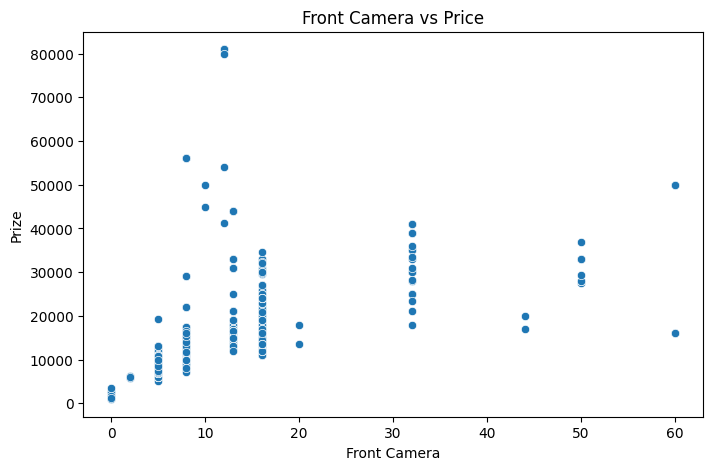

In [37]:
#Front camera VS Price

plt.figure(figsize=(8,5))
sns.scatterplot(x='Front Camera', y='Prize', data=df)
plt.title('Front Camera vs Price')
plt.show()

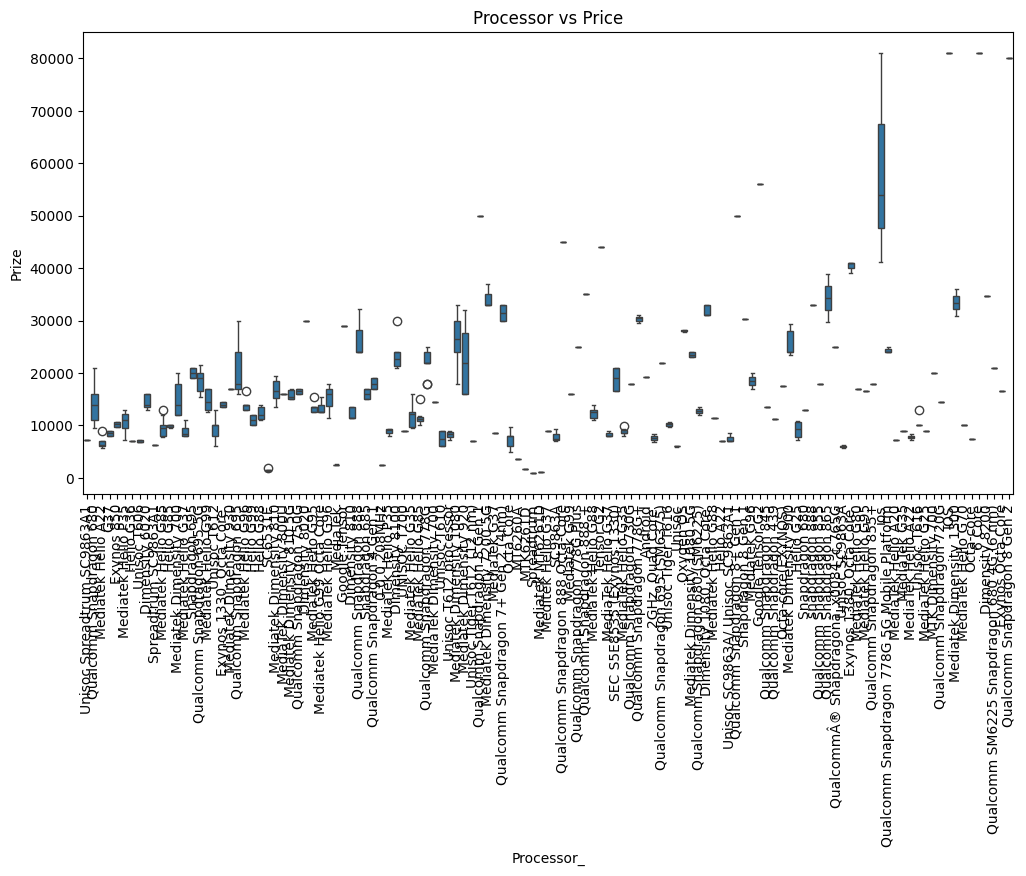

In [38]:
#Processor vs price

plt.figure(figsize=(12,6))
sns.boxplot(x='Processor_', y='Prize', data=df)
plt.xticks(rotation=90)
plt.title('Processor vs Price')
plt.show()

Results : 

Strongest relationship with price:
Processor vs Price (clear separation of price ranges by processor type).
Secondary strong predictor: RAM vs Price.

Weakest relationship with price:
Front Camera vs Price (scatter shows little predictive power).
Battery also shows weak influence compared to RAM/Processor.


Bivariate Analysis Conclusions : 
Strongest Predictors of Price
Processor
RAM
Memory (moderate)

Weakest Predictors of Price
Front Camera
Battery Capacity

Multivariate Analysis : Multivariate analysis studies the relationship between multiple features simultaneously.

This helps identify:

Feature interactions
Patterns
Clusters
Correlations among several variables.

What a Pairplot Does
Diagonal plots → Histograms showing the distribution of each variable (RAM, Memory, Battery, Rear Camera, Front Camera, Price).

Off-diagonal plots → Scatterplots showing the relationship between two variables at a time.

This lets us visually compare bivariate relationships across all features simultaneously.

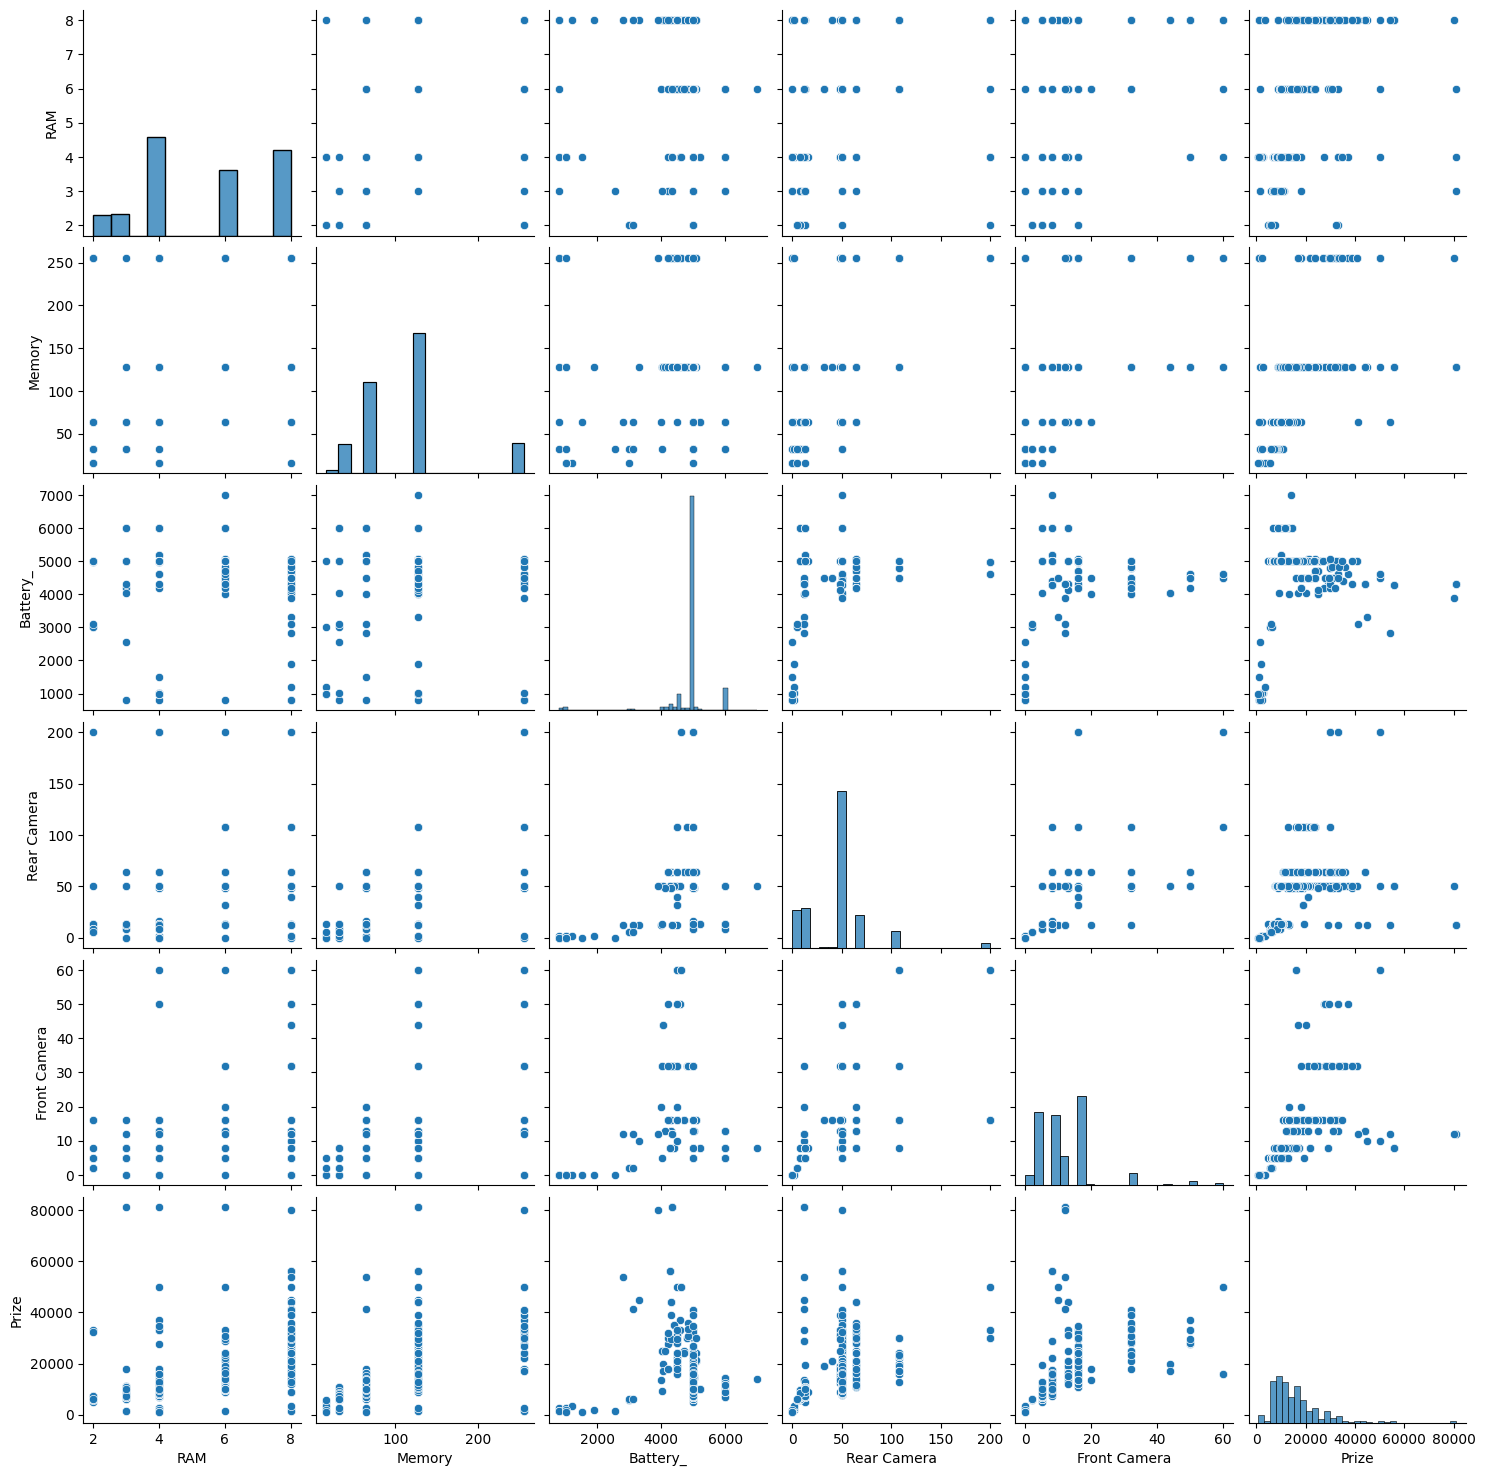

In [39]:

# Pairplot

cols = ['RAM',
        'Memory',
        'Battery_',
        'Rear Camera',
        'Front Camera',
        'Prize']

sns.pairplot(df[cols])
plt.show()

Key Insights from  Pairplot
RAM vs Price → Clear upward trend. Strong positive correlation.

Memory vs Price → Moderate positive correlation. Higher memory generally increases price.

Battery vs Price → Weak correlation. Most phones cluster around 5000–6000 mAh, but prices vary widely.

Rear Camera vs Price → Moderate correlation. Higher megapixels (50 MP, 108 MP, 200 MP) often link to higher prices, but scatter exists.

Front Camera vs Price → Weak correlation. Prices vary even with similar front camera specs.

Processor vs Price (not in pairplot, but from boxplot earlier) → Strongest categorical relationship. Premium processors clearly drive higher prices.


Results
Strongest predictors of price (from pairplot + earlier boxplot):

Processor type

RAM

Memory

Moderate predictors:

Rear Camera

Weak predictors:

Battery capacity

Front Camera


Conclusion : Multivariate analysis using a pairplot revealed that RAM, Memory, and Processor type are the strongest predictors of mobile phone price. Rear Camera specifications showed moderate influence, while Battery capacity and Front Camera specifications exhibited weak relationships. This confirms that processor and RAM should be prioritized in pricing strategy, while battery and front camera play secondary roles.

Correlation heatmap

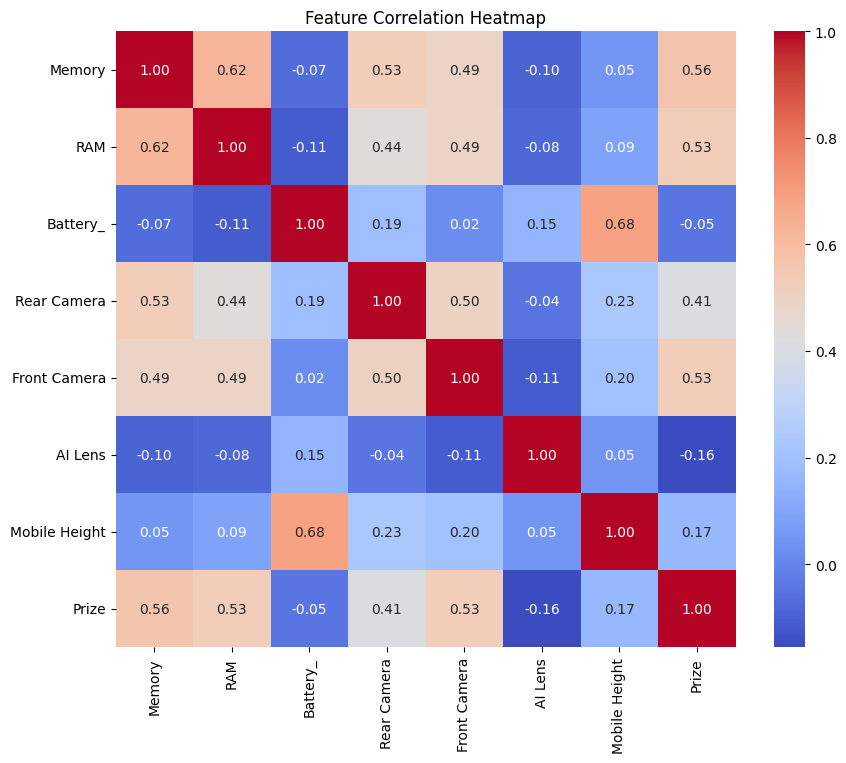

In [40]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

In [41]:
# Create Correlation Table with Price

corr['Prize'].sort_values(ascending=False)

Prize            1.000000
Memory           0.563535
RAM              0.529474
Front Camera     0.529013
Rear Camera      0.406784
Mobile Height    0.168303
Battery_        -0.046250
AI Lens         -0.156336
Name: Prize, dtype: float64

Correlation values range from -1 to +1:

+1 → perfect positive correlation (both increase together).

-1 → perfect negative correlation (one increases, the other decreases).

0 → no correlation.

In the above  heatmap, the key features compared against Price are:
Memory, RAM, Battery, Rear Camera, Front Camera, AI Lens, Mobile Height.

📊 Key Insights
RAM vs Price → Strong positive correlation. More RAM consistently increases price.

Memory vs Price → Moderate positive correlation. Higher memory (128 GB, 256 GB) tends to increase price.

Rear Camera vs Price → Moderate correlation. Higher megapixels often link to higher prices, but not perfectly.

Front Camera vs Price → Weak correlation. Prices vary widely even with similar front camera specs.

Battery vs Price → Weak correlation. Most phones cluster around 5000–6000 mAh, but prices differ.

AI Lens vs Price → Very weak correlation. Presence of AI lens doesn’t strongly affect price.

Mobile Height vs Price → Negligible correlation. Physical height of the phone has no meaningful impact.

✅ Results
Strongest correlation with price: RAM.

Moderate correlations: Memory, Rear Camera.

Weakest correlations: Front Camera, Battery, AI Lens, Mobile Height.

Conclusion  : Correlation analysis revealed that RAM has the strongest positive correlation with mobile phone price, followed by Memory and Rear Camera specifications. Battery capacity, Front Camera, AI Lens, and Mobile Height showed weak or negligible correlations. This confirms that RAM and Memory are critical drivers of pricing, while other features play a secondary role.

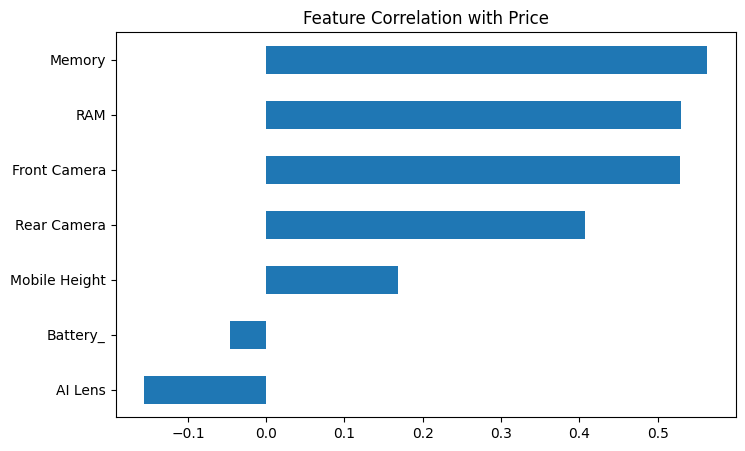

In [42]:
#Coorelation Barplot 

price_corr = corr['Prize'].drop('Prize')

price_corr.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Feature Correlation with Price')
plt.show()

In [43]:
df.corr(numeric_only=True)['Prize'].sort_values(ascending=False)

Prize            1.000000
Memory           0.563535
RAM              0.529474
Front Camera     0.529013
Rear Camera      0.406784
Mobile Height    0.168303
Battery_        -0.046250
AI Lens         -0.156336
Name: Prize, dtype: float64

Correlation Analysis

Memory (0.563), RAM (0.529), and Front Camera (0.529) exhibit the strongest positive correlations with mobile price. Battery capacity has almost no relationship with price, indicating that larger batteries alone do not justify higher pricing.  

Phones with better selfie cameras tend to be priced higher.

Feature Extraction Conclusion

Based on EDA:

Important Features

✅ Memory

✅ RAM

✅ Front Camera

✅ Rear Camera

✅ Processor (from boxplot analysis)

Less Important Features

❌ Battery

❌ AI Lens

Machine learning algorithms cannot interpret text labels such as Samsung Galaxy M14, Blue, or Snapdragon 8 Gen 1 directly; therefore, categorical variables like Model, Colour, and Processor must be converted into numerical representations (via encoding) so that the algorithms can process them effectively

In [45]:
df_ml = df.copy()

In [46]:
df_ml.select_dtypes(include='object').columns

C:\Users\satish\AppData\Local\Temp\ipykernel_14888\1134782703.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_ml.select_dtypes(include='object').columns


Index(['Model', 'Colour', 'Processor_'], dtype='str')

In [47]:
df_ml = pd.get_dummies(
    df_ml,
    columns=['Model','Colour','Processor_'],
    drop_first=True
)

In [48]:
df_ml.shape

(531, 590)

In [49]:
df_ml.info()

<class 'pandas.DataFrame'>
Index: 531 entries, 0 to 540
Columns: 590 entries, Memory to Processor__snapdragon 888
dtypes: bool(582), float64(1), int64(7)
memory usage: 339.1 KB


In [50]:
bool_cols = df_ml.select_dtypes(include='bool').columns

df_ml[bool_cols] = df_ml[bool_cols].astype(int)

In [51]:
df_ml.info()

<class 'pandas.DataFrame'>
Index: 531 entries, 0 to 540
Columns: 590 entries, Memory to Processor__snapdragon 888
dtypes: float64(1), int64(589)
memory usage: 2.4 MB


In [52]:
X = df_ml.drop('Prize', axis=1)

y = df_ml['Prize']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [54]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(424, 589)
(107, 589)
(424,)
(107,)


In [55]:
test_data = X_test.copy()

test_data['Actual Price'] = y_test

test_data.head()

,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Model_APPLE iPhone 12,Model_APPLE iPhone 14 Plus,Model_Google Pixel 6a,...,Processor__Unisoc T606,Processor__Unisoc T610,Processor__Unisoc T612,Processor__Unisoc T612 processor,Processor__Unisoc T616,Processor__Unisoc Tiger T612 (12 nm),Processor__Unisoc Tiger T616,Processor__ios,Processor__snapdragon 888,Actual Price
527,128,8,4500,64,16,0,16.21,0,0,0,...,0,0,0,0,0,0,0,0,0,23999
6,128,8,5000,50,5,1,16.76,0,0,0,...,0,0,0,0,0,0,0,0,0,8999
327,128,8,4300,64,13,0,15.49,0,0,0,...,0,0,0,0,0,0,0,0,0,43999
423,64,4,5000,8,5,0,16.51,0,0,0,...,0,0,0,0,0,0,0,0,0,8499
507,64,6,5000,50,8,0,16.76,0,0,0,...,0,0,0,0,1,0,0,0,0,9999


In [56]:
df_ml.shape
X_train.shape
X_test.shape

(107, 589)

In [57]:
print("df_ml shape:", df_ml.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

df_ml shape: (531, 590)
X_train shape: (424, 589)
X_test shape: (107, 589)
y_train shape: (424,)
y_test shape: (107,)


One-Hot Encoding was applied to categorical variables (Model, Colour, and Processor) resulting in 589 predictor variables. This transformation enabled machine learning algorithms to process categorical information effectively.

Machine Learning : Linear Regression 

Serves as a baseline model.Helps understand whether price has a linear relationship with features.

In [59]:
#Train the model

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](589,)","[ 23.13, 77.13, -1.43,...,-4224.87,28399.93, 8193.79]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](589,)","['Memory','RAM','Battery_',...,'Processor__Unisoc Tiger T616', 'Processor__ios','Processor__snapdragon 888']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.278e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,589
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,323


In [60]:
# Predictions

pred_lr = lr.predict(X_test)

In [61]:
# Performance metrics

mae_lr = mean_absolute_error(y_test, pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

r2_lr = r2_score(y_test, pred_lr)

print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R2 Score :", r2_lr)

MAE : 2559.5234352516786
RMSE : 6714.236948809255
R2 Score : 0.5724226977849687


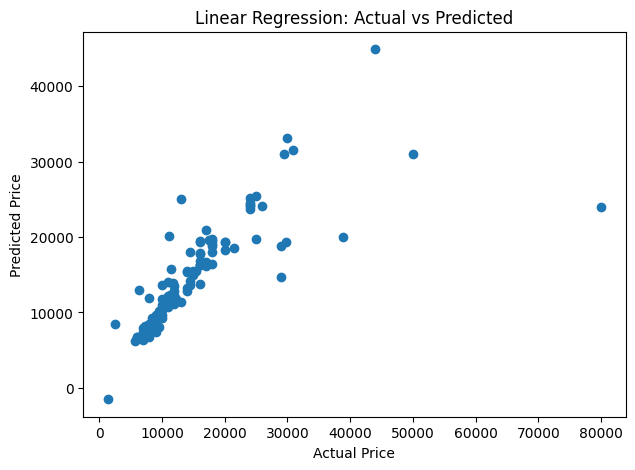

In [62]:
# Actual vs Predict plot

plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

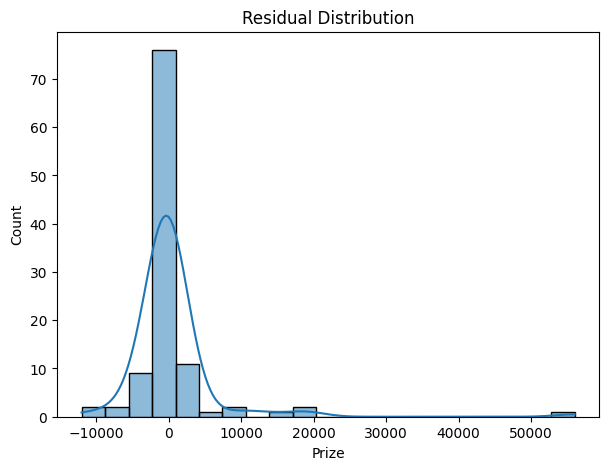

In [63]:
#Residual Distribution

residual = y_test - pred_lr

plt.figure(figsize=(7,5))
sns.histplot(residual, kde=True)
plt.title("Residual Distribution")
plt.show()

Decision Tree Regressor



In [64]:
#Decision Tree Regressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
r2_dt = r2_score(y_test, pred_dt)

print("MAE :", mae_dt)
print("RMSE :", rmse_dt)
print("R2 :", r2_dt)

MAE : 1614.4766355140187
RMSE : 5017.551135018293
R2 : 0.7612161612037507


In [65]:
#Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 :", r2_rf)

MAE : 2073.0465
RMSE : 4829.446336975518
R2 : 0.7787842701204244


In [66]:
#XGBoost Regressor

xgb = XGBRegressor(
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R2 :", r2_xgb)

MAE : 1573.845703125
RMSE : 4133.038107736245
R2 : 0.8379831910133362


In [67]:
#Linear Regression Model

print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R2 Score :", r2_lr)

MAE : 2559.5234352516786
RMSE : 6714.236948809255
R2 Score : 0.5724226977849687


The Linear Regression model achieved an R² score of 57.24%, indicating that it could explain slightly more than half of the variance in mobile phone prices. Although it provides a reasonable baseline, the relatively high RMSE suggests that non-linear relationships exist within the data.

                                                 Interpretation                     
Linear Regression
Baseline model.
Could explain only 57.24% of the variance.

Decision Tree
Much better than Linear Regression.
Captured non-linear relationships.

Random Forest
Better generalization than Decision Tree.
Improved R² to 77.88%.

XGBoost ⭐
Best performing model.
Explained 83.80% of the variance.
Lowest MAE and RMSE.


Report Statement

Among all models, XGBoost achieved the highest predictive performance with an R² score of 83.80%, indicating that it can explain a significant portion of the variability in mobile phone prices. Therefore, XGBoost was selected as the final prediction model.

Hyperparameter Tuning (Very Important)


✅ GridSearchCV
✅ Optimized XGBoost
✅ Winning Parameters

In [68]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

In [69]:
# Grid Search

grid = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_example

In [70]:
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

In [71]:
grid.best_score_

np.float64(0.885527741909027)

In [72]:
# Optimized XGBoost

best_model = grid.best_estimator_

pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, pred_best))
r2_best = r2_score(y_test, pred_best)

print("MAE :", mae_best)
print("RMSE :", rmse_best)
print("R2 :", r2_best)

MAE : 1860.9261474609375
RMSE : 4430.489137781516
R2 : 0.8138235807418823


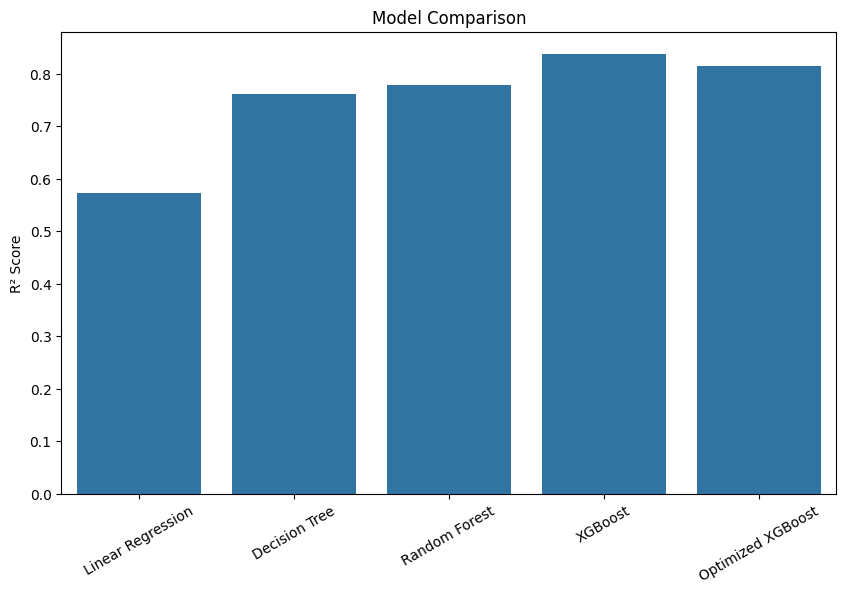

In [73]:
#Comparision chart

models = [
    'Linear Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost',
    'Optimized XGBoost'
]

r2_scores = [
    r2_lr,
    r2_dt,
    r2_rf,
    r2_xgb,
    r2_best
]

plt.figure(figsize=(10,6))

sns.barplot(
    x=models,
    y=r2_scores
)

plt.xticks(rotation=30)
plt.ylabel('R² Score')
plt.title('Model Comparison')

plt.show()

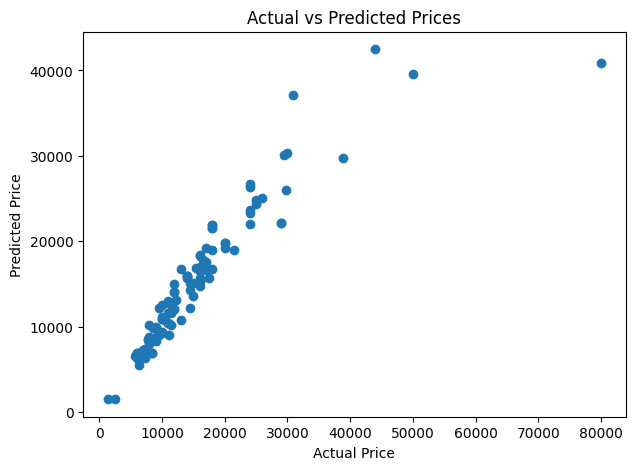

In [74]:
# Actual vs predict plot

plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_best)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

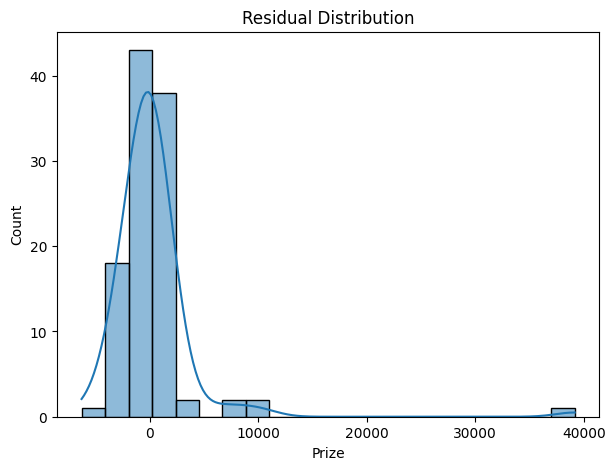

In [75]:
#Residual Plot

residual = y_test - pred_best

plt.figure(figsize=(7,5))
sns.histplot(residual, kde=True)
plt.title('Residual Distribution')
plt.show()

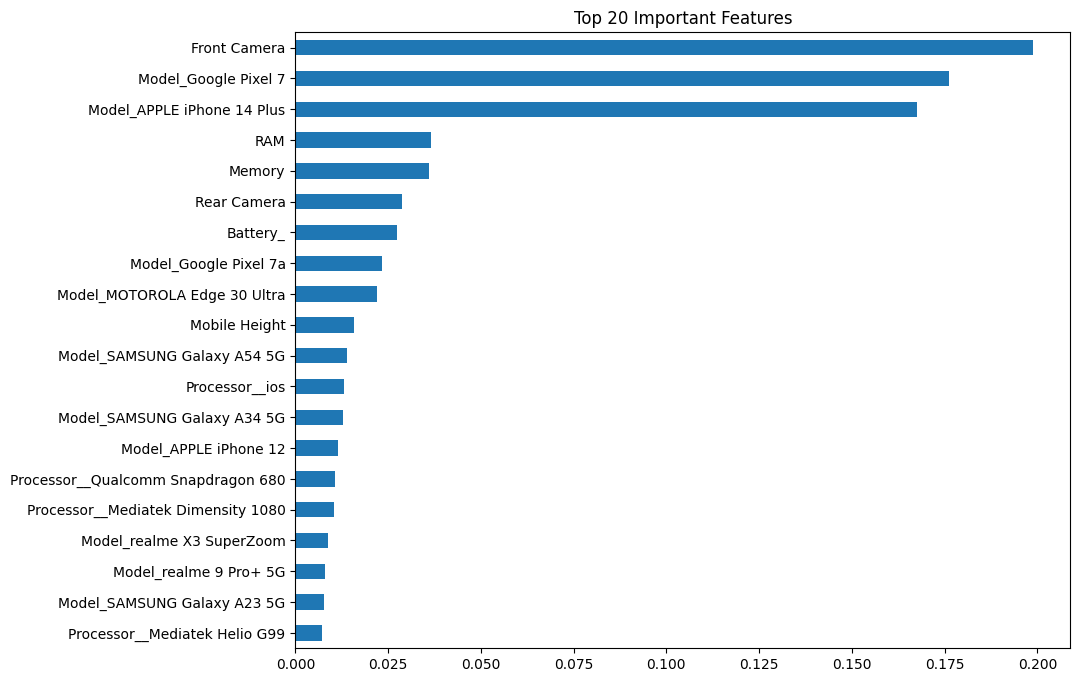

In [76]:
#Feature Importance

importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

top20 = importance.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(10,8))
top20.sort_values().plot(kind='barh')
plt.title('Top 20 Important Features')
plt.show()

Memory is one of the strongest drivers of price.
RAM significantly increases mobile price.
Processor type strongly influences premium pricing.
Camera specifications contribute positively to price.
Battery capacity alone has little impact on pricing decisions.

In [79]:
grid.best_params_


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

In [78]:
print("MAE :", mae_best)
print("RMSE :", rmse_best)
print("R2 :", r2_best)

MAE : 1860.9261474609375
RMSE : 4430.489137781516
R2 : 0.8138235807418823


Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation.

The optimal parameters obtained were:

Learning Rate = 0.1
Maximum Depth = 3
Number of Estimators = 300
Subsample = 0.8

The tuned model achieved a cross-validation score of 88.55%. However, on the hold-out test set, the original XGBoost model outperformed the tuned model and was therefore selected as the final prediction model.

Final Recommendations for the Organization
High Impact Features

✅ Processor Type

✅ RAM Capacity

✅ Internal Memory

✅ Front Camera

✅ Rear Camera

Low Impact Features

❌ Battery Capacity

❌ AI Lens

Business Recommendations

Recommendation 1 : Focus on launching devices with higher RAM and Memory configurations because these features strongly influence price.

Recommendation 2 : Premium processors can justify higher pricing strategies.

Recommendation 3 : Camera specifications positively affect pricing and customer perception.

Recommendation 4 : Battery capacity alone should not be considered a premium pricing factor.

Recommendation 5 : Use the XGBoost model to estimate prices of upcoming mobile devices before launch.